# CP1. EDA и подготовка данных

В этом ноутбуке проводится первичный анализ датасета Airline Customer Satisfaction и подготовка данных для решения задачи бинарной классификации.

Цель проекта - предсказать, будет ли пассажир удовлетворён перелётом, на основе характеристик поездки, класса обслуживания, задержек и оценок качества сервиса.

Целевой признак - `satisfaction`.

В используемой версии датасета целевая переменная принимает два значения:

- `satisfied` - пассажир удовлетворён;
- `dissatisfied` - пассажир не удовлетворён.

## Источник данных и постановка задачи

Для проекта выбран датасет Airline Customer Satisfaction с Kaggle.

Данные подходят для проекта, так как содержат явный целевой признак, достаточное количество наблюдений и набор признаков разных типов: характеристики клиента, параметры поездки, класс обслуживания, расстояние перелёта, задержки и оценки качества сервиса.

Задача сводится к бинарной классификации: по имеющимся признакам необходимо предсказать, относится ли пассажир к классу `satisfied`.

In [2]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE = 506

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_IMAGES_DIR = PROJECT_ROOT / "report" / "images"
REPORT_TABLES_DIR = PROJECT_ROOT / "report" / "tables"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
REPORT_IMAGES_DIR.mkdir(parents=True, exist_ok=True)
REPORT_TABLES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)

## Загрузка данных

Исходный CSV-файл находится в папке `data/raw/`.

In [3]:
csv_files = sorted(RAW_DATA_DIR.glob("*.csv"))

if len(csv_files) == 0:
    raise FileNotFoundError(f"No CSV files found in {RAW_DATA_DIR}")

data_raw = pd.read_csv(csv_files[0])

print(f"Dataset shape: {data_raw.shape}")
data_raw.head()

Dataset shape: (129880, 22)


,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,2,4,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,0,2,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,2,0,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,3,4,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,4,3,4,2,2,0,2,4,2,5,0,0.0


## Размер датасета

На этом шаге проверяется, соответствует ли датасет базовым требованиям проекта по объёму: не менее 10 000 строк и не менее 10 колонок, включая целевой признак.

In [4]:
rows_count = data_raw.shape[0]
columns_count = data_raw.shape[1]

dataset_overview = pd.DataFrame(
    {
        "metric": [
            "rows",
            "columns",
            "passes_rows_requirement",
            "passes_columns_requirement",
        ],
        "value": [
            rows_count,
            columns_count,
            rows_count >= 10000,
            columns_count >= 10,
        ],
    }
)

dataset_overview

,metric,value
0,rows,129880
1,columns,22
2,passes_rows_requirement,True
3,passes_columns_requirement,True


Датасет содержит 129 880 строк и 22 исходные колонки, включая целевой признак `satisfaction`.

## Названия признаков

В исходном файле названия колонок записаны в разном стиле: с пробелами, заглавными буквами и специальными символами. Для удобства дальнейшей обработки все названия приводятся к формату `snake_case`.

In [6]:
def normalize_column_name(column: str) -> str:
    column = column.strip().lower()
    column = re.sub(r"[^a-z0-9]+", "_", column)
    column = re.sub(r"_+", "_", column)
    return column.strip("_")


data = data_raw.copy()
data.columns = [normalize_column_name(column) for column in data.columns]

data.head()

,satisfaction,customer_type,age,type_of_travel,class,flight_distance,seat_comfort,departure_arrival_time_convenient,food_and_drink,gate_location,inflight_wifi_service,inflight_entertainment,online_support,ease_of_online_booking,on_board_service,leg_room_service,baggage_handling,checkin_service,cleanliness,online_boarding,departure_delay_in_minutes,arrival_delay_in_minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,2,4,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,0,2,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,2,0,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,3,4,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,4,3,4,2,2,0,2,4,2,5,0,0.0


In [7]:
data.columns.tolist()

['satisfaction',
 'customer_type',
 'age',
 'type_of_travel',
 'class',
 'flight_distance',
 'seat_comfort',
 'departure_arrival_time_convenient',
 'food_and_drink',
 'gate_location',
 'inflight_wifi_service',
 'inflight_entertainment',
 'online_support',
 'ease_of_online_booking',
 'on_board_service',
 'leg_room_service',
 'baggage_handling',
 'checkin_service',
 'cleanliness',
 'online_boarding',
 'departure_delay_in_minutes',
 'arrival_delay_in_minutes']

## Типы признаков

В датасете присутствуют числовые и категориальные признаки.

Числовые признаки будут обрабатываться через масштабирование, а категориальные - через кодирование.

In [8]:
target_column = "satisfaction"

numeric_columns = (
    data.drop(columns=[target_column])
    .select_dtypes(include=["number"])
    .columns
    .tolist()
)

categorical_columns = (
    data.drop(columns=[target_column])
    .select_dtypes(exclude=["number"])
    .columns
    .tolist()
)

print("Numeric columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numeric columns:
['age', 'flight_distance', 'seat_comfort', 'departure_arrival_time_convenient', 'food_and_drink', 'gate_location', 'inflight_wifi_service', 'inflight_entertainment', 'online_support', 'ease_of_online_booking', 'on_board_service', 'leg_room_service', 'baggage_handling', 'checkin_service', 'cleanliness', 'online_boarding', 'departure_delay_in_minutes', 'arrival_delay_in_minutes']

Categorical columns:
['customer_type', 'type_of_travel', 'class']


In [9]:
dtypes = (
    data.dtypes.astype(str)
    .reset_index()
    .rename(columns={"index": "column", 0: "dtype"})
)

dtypes.to_csv(REPORT_TABLES_DIR / "dtypes.csv", index=False)
dtypes

,column,dtype
0,satisfaction,str
1,customer_type,str
2,age,int64
3,type_of_travel,str
4,class,str
5,flight_distance,int64
6,seat_comfort,int64
7,departure_arrival_time_convenient,int64
8,food_and_drink,int64
9,gate_location,int64


## Пропущенные значения

Далее проверяется наличие пропусков в данных. Для числовых признаков выбран способ заполнения медианой, так как медиана менее чувствительна к выбросам, чем среднее значение. Для категориальных признаков при необходимости используется наиболее частое значение.

In [10]:
missing_before = (
    data.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)

missing_before["missing_share"] = missing_before["missing_count"] / len(data)
missing_before = missing_before.sort_values("missing_count", ascending=False)

missing_before

,column,missing_count,missing_share
21,arrival_delay_in_minutes,393,0.003026
0,satisfaction,0,0.000000
2,age,0,0.000000
3,type_of_travel,0,0.000000
4,class,0,0.000000
1,customer_type,0,0.000000
5,flight_distance,0,0.000000
6,seat_comfort,0,0.000000
8,food_and_drink,0,0.000000
7,departure_arrival_time_convenient,0,0.000000


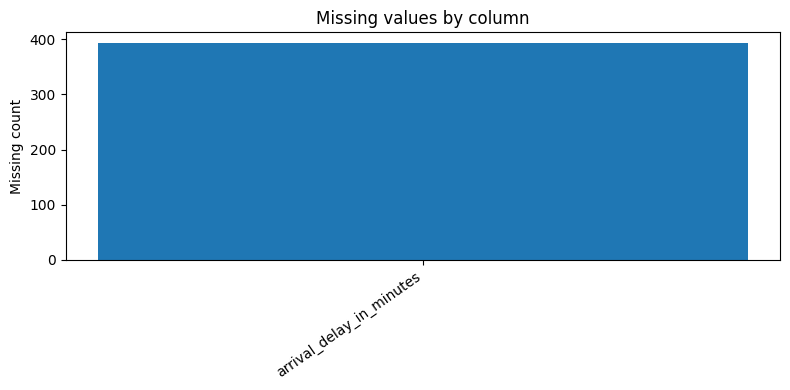

In [11]:
missing_before.to_csv(
    REPORT_TABLES_DIR / "missing_values_before_cleaning.csv",
    index=False,
)

missing_non_zero = missing_before[missing_before["missing_count"] > 0]

if not missing_non_zero.empty:
    plt.figure(figsize=(8, 4))
    plt.bar(missing_non_zero["column"], missing_non_zero["missing_count"])
    plt.xticks(rotation=35, ha="right")
    plt.title("Missing values by column")
    plt.ylabel("Missing count")
    plt.tight_layout()
    plt.savefig(REPORT_IMAGES_DIR / "missing_values.png", dpi=200)
    plt.show()
else:
    print("Пропусков в датасете не обнаружено.")

In [12]:
data_clean = data.copy()

numeric_columns_with_missing = [
    column for column in numeric_columns if data_clean[column].isna().sum() > 0
]

categorical_columns_with_missing = [
    column for column in categorical_columns if data_clean[column].isna().sum() > 0
]

for column in numeric_columns_with_missing:
    median_value = data_clean[column].median()
    data_clean[column] = data_clean[column].fillna(median_value)
    print(f"{column}: filled with median = {median_value}")

for column in categorical_columns_with_missing:
    mode_value = data_clean[column].mode()[0]
    data_clean[column] = data_clean[column].fillna(mode_value)
    print(f"{column}: filled with mode = {mode_value}")

arrival_delay_in_minutes: filled with median = 0.0


In [13]:
missing_after = (
    data_clean.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)

missing_after["missing_share"] = missing_after["missing_count"] / len(data_clean)
missing_after = missing_after.sort_values("missing_count", ascending=False)

missing_after.to_csv(
    REPORT_TABLES_DIR / "missing_values_after_cleaning.csv",
    index=False,
)

missing_after.head()

,column,missing_count,missing_share
0,satisfaction,0,0.0
1,customer_type,0,0.0
2,age,0,0.0
3,type_of_travel,0,0.0
4,class,0,0.0


## Дубли

Полностью повторяющиеся строки могут искажать обучение модели, так как один и тот же объект будет учитываться несколько раз. Поэтому перед моделированием проверяется количество дублей и при необходимости они удаляются.

In [14]:
duplicates_before = data_clean.duplicated().sum()

data_clean = data_clean.drop_duplicates()

duplicates_after = data_clean.duplicated().sum()

print(f"Duplicates before: {duplicates_before}")
print(f"Duplicates after: {duplicates_after}")
print(f"Rows after duplicate removal: {data_clean.shape[0]}")

Duplicates before: 0
Duplicates after: 0
Rows after duplicate removal: 129880


## Целевой признак

Распределение целевого признака показывает баланс классов в задаче. Это важно учитывать при выборе метрик и при разделении данных на train, validation и test.

Для моделирования целевой признак кодируется следующим образом:

- `dissatisfied` → 0;
- `satisfied` → 1.

In [15]:
target_counts = data_clean[target_column].value_counts()
target_share = data_clean[target_column].value_counts(normalize=True)

target_distribution = pd.DataFrame(
    {
        "count": target_counts,
        "share": target_share,
    }
)

target_distribution

,count,share
satisfaction,,
satisfied,71087,0.547328
dissatisfied,58793,0.452672


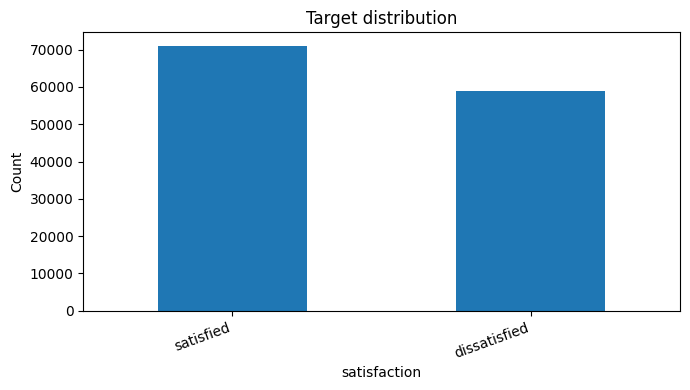

In [16]:
target_distribution.to_csv(REPORT_TABLES_DIR / "target_distribution.csv")

plt.figure(figsize=(7, 4))
target_counts.plot(kind="bar")
plt.title("Target distribution")
plt.ylabel("Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / "target_distribution.png", dpi=200)
plt.show()

In [17]:
target_mapping = {
    "dissatisfied": 0,
    "neutral or dissatisfied": 0,
    "satisfied": 1,
}

data_clean["target"] = (
    data_clean[target_column]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(target_mapping)
)

if data_clean["target"].isna().any():
    unknown_values = data_clean.loc[data_clean["target"].isna(), target_column].unique()
    raise ValueError(f"Unknown target values: {unknown_values}")

data_clean[["satisfaction", "target"]].head()

,satisfaction,target
0,satisfied,1
1,satisfied,1
2,satisfied,1
3,satisfied,1
4,satisfied,1


## Выбросы

Основные потенциальные выбросы в этом датасете связаны с задержками рейсов. Большие значения задержек могут быть реальными, но они создают длинный хвост распределения и могут непропорционально влиять на линейные модели и методы, чувствительные к масштабу признаков.

Поэтому для признаков `departure_delay_in_minutes` и `arrival_delay_in_minutes` все значения выше 99-го перцентиля заменяются на значение 99-го перцентиля.

In [18]:
data_clean[
    [
        "age",
        "flight_distance",
        "departure_delay_in_minutes",
        "arrival_delay_in_minutes",
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
age,129880.0,39.427957,15.119360,7.0,27.0,40.0,51.0,85.0
flight_distance,129880.0,1981.409055,1027.115606,50.0,1359.0,1925.0,2544.0,6951.0
departure_delay_in_minutes,129880.0,14.713713,38.071126,0.0,0.0,0.0,12.0,1592.0
arrival_delay_in_minutes,129880.0,15.045465,38.416353,0.0,0.0,0.0,13.0,1584.0


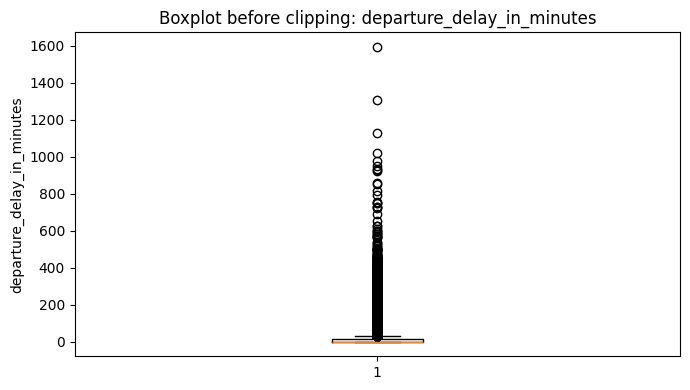

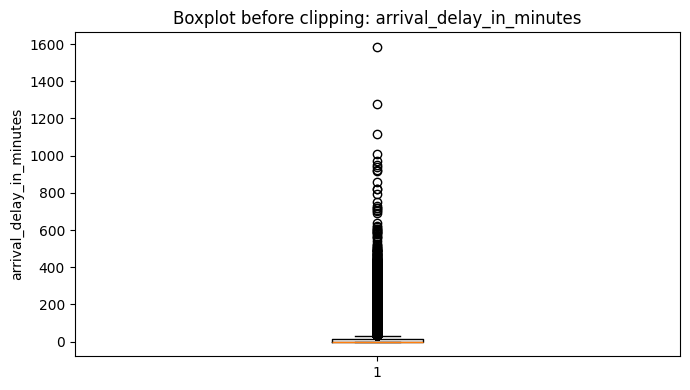

In [19]:
delay_columns = [
    "departure_delay_in_minutes",
    "arrival_delay_in_minutes",
]

for column in delay_columns:
    plt.figure(figsize=(7, 4))
    plt.boxplot(data_clean[column])
    plt.title(f"Boxplot before clipping: {column}")
    plt.ylabel(column)
    plt.tight_layout()
    plt.savefig(REPORT_IMAGES_DIR / f"boxplot_before_{column}.png", dpi=200)
    plt.show()

In [20]:
outlier_summary = []

for column in delay_columns:
    upper_bound = data_clean[column].quantile(0.99)
    max_before = data_clean[column].max()
    data_clean[column] = data_clean[column].clip(upper=upper_bound)
    max_after = data_clean[column].max()

    outlier_summary.append(
        {
            "column": column,
            "max_before": max_before,
            "upper_bound_99_quantile": upper_bound,
            "max_after": max_after,
        }
    )

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary.to_csv(
    REPORT_TABLES_DIR / "outlier_processing_summary.csv",
    index=False,
)

outlier_summary

,column,max_before,upper_bound_99_quantile,max_after
0,departure_delay_in_minutes,1592.0,180.0,180.0
1,arrival_delay_in_minutes,1584.0,182.0,182.0


## Feature engineering

На основе исходных признаков добавляются несколько новых признаков:

- `total_delay` - суммарная задержка вылета и прилёта;
- `has_delay` - бинарный признак наличия задержки;
- `is_long_flight` - бинарный признак длинного перелёта;
- `mean_service_score` - средняя оценка качества сервиса.

Эти признаки объединяют уже имеющуюся информацию и могут помочь моделям лучше учитывать общий уровень задержек и сервиса.

In [21]:
data_clean["total_delay"] = (
    data_clean["departure_delay_in_minutes"]
    + data_clean["arrival_delay_in_minutes"]
)

data_clean["has_delay"] = (data_clean["total_delay"] > 0).astype(int)

data_clean["is_long_flight"] = (data_clean["flight_distance"] > 1500).astype(int)

service_columns = [
    "seat_comfort",
    "departure_arrival_time_convenient",
    "food_and_drink",
    "gate_location",
    "inflight_wifi_service",
    "inflight_entertainment",
    "online_support",
    "ease_of_online_booking",
    "on_board_service",
    "leg_room_service",
    "baggage_handling",
    "checkin_service",
    "cleanliness",
    "online_boarding",
]

data_clean["mean_service_score"] = data_clean[service_columns].mean(axis=1)

data_clean[
    [
        "total_delay",
        "has_delay",
        "is_long_flight",
        "mean_service_score",
    ]
].head()

,total_delay,has_delay,is_long_flight,mean_service_score
0,0.0,0,0,2.071429
1,362.0,1,1,2.071429
2,0.0,0,1,2.071429
3,0.0,0,0,1.714286
4,0.0,0,0,2.214286


In [22]:
feature_engineering_summary = pd.DataFrame(
    {
        "feature": [
            "total_delay",
            "has_delay",
            "is_long_flight",
            "mean_service_score",
        ],
        "description": [
            "sum of departure and arrival delays",
            "binary flag for any delay",
            "binary flag for flights longer than 1500",
            "average score across service-related features",
        ],
    }
)

feature_engineering_summary.to_csv(
    REPORT_TABLES_DIR / "feature_engineering_summary.csv",
    index=False,
)

feature_engineering_summary

,feature,description
0,total_delay,sum of departure and arrival delays
1,has_delay,binary flag for any delay
2,is_long_flight,binary flag for flights longer than 1500
3,mean_service_score,average score across service-related features


## Анализ зависимостей

На этом этапе строятся визуализации, которые помогают оценить связь признаков с целевой переменной.

Особое внимание уделяется категориальным признакам `class`, `type_of_travel` и `customer_type` и агрегированному признаку `mean_service_score`.

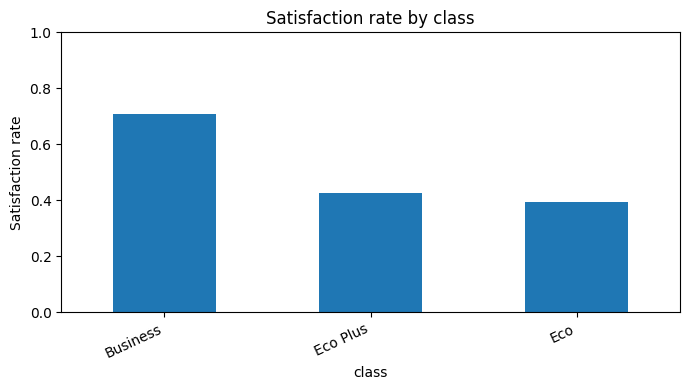

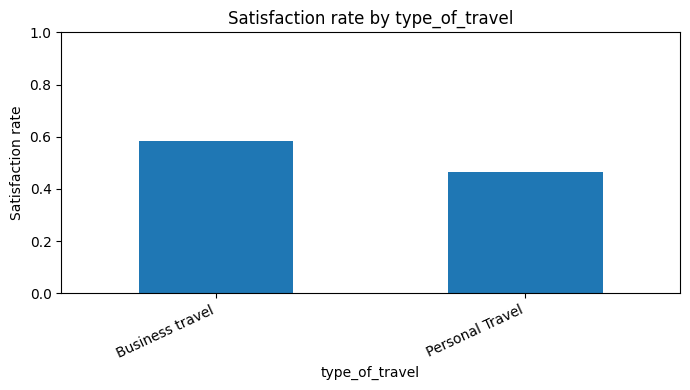

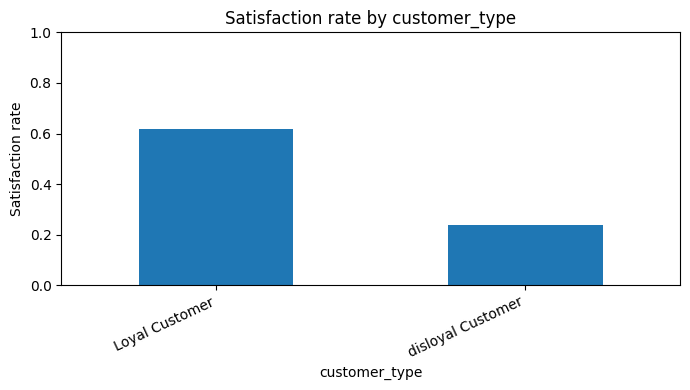

In [23]:
for column in ["class", "type_of_travel", "customer_type"]:
    satisfaction_rate = (
        data_clean.groupby(column)["target"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(7, 4))
    satisfaction_rate.plot(kind="bar")
    plt.title(f"Satisfaction rate by {column}")
    plt.ylabel("Satisfaction rate")
    plt.ylim(0, 1)
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.savefig(REPORT_IMAGES_DIR / f"satisfaction_rate_by_{column}.png", dpi=200)
    plt.show()

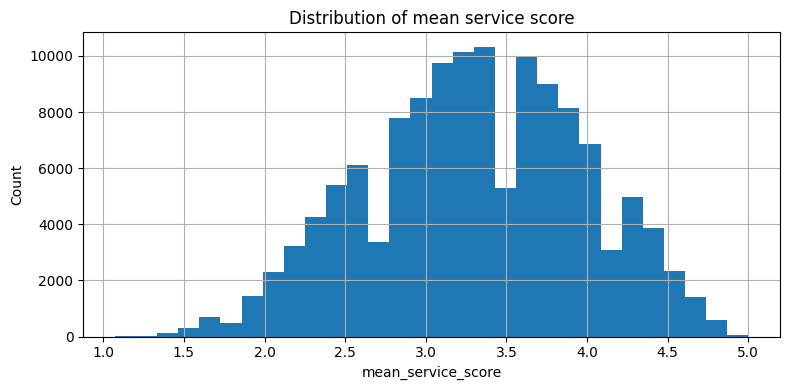

In [31]:
plt.figure(figsize=(8, 4))
data_clean["mean_service_score"].hist(bins=30)
plt.title("Distribution of mean service score")
plt.xlabel("mean_service_score")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / "distribution_mean_service_score.png", dpi=200)
plt.show()

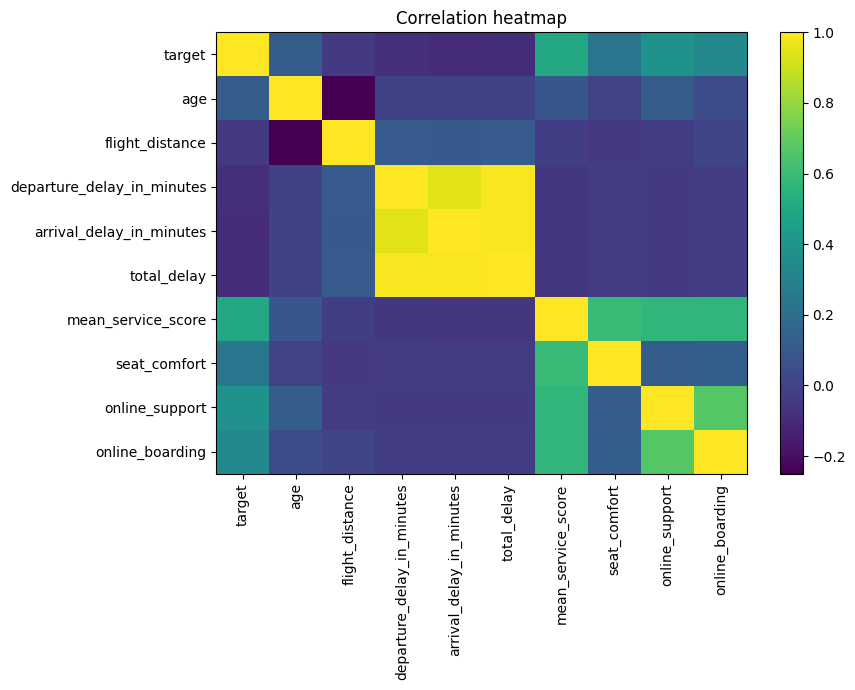

,target,age,flight_distance,departure_delay_in_minutes,arrival_delay_in_minutes,total_delay,mean_service_score,seat_comfort,online_support,online_boarding
target,1.000000,0.117971,-0.039224,-0.080959,-0.089168,-0.086268,0.506039,0.242384,0.390143,0.338147
age,0.117971,1.000000,-0.249625,-0.007739,-0.009959,-0.008978,0.083178,0.008784,0.121201,0.037973
flight_distance,-0.039224,-0.249625,1.000000,0.108307,0.105457,0.108356,-0.020177,-0.042409,-0.032022,0.009604
departure_delay_in_minutes,-0.080959,-0.007739,0.108307,1.000000,0.945643,0.986152,-0.046040,-0.025856,-0.035966,-0.022308
arrival_delay_in_minutes,-0.089168,-0.009959,0.105457,0.945643,1.000000,0.986481,-0.052243,-0.027969,-0.038883,-0.025006
total_delay,-0.086268,-0.008978,0.108356,0.986152,0.986481,1.000000,-0.049842,-0.027292,-0.037953,-0.023993
mean_service_score,0.506039,0.083178,-0.020177,-0.046040,-0.052243,-0.049842,1.000000,0.595781,0.572662,0.571567
seat_comfort,0.242384,0.008784,-0.042409,-0.025856,-0.027969,-0.027292,0.595781,1.000000,0.120278,0.130396
online_support,0.390143,0.121201,-0.032022,-0.035966,-0.038883,-0.037953,0.572662,0.120278,1.000000,0.669843
online_boarding,0.338147,0.037973,0.009604,-0.022308,-0.025006,-0.023993,0.571567,0.130396,0.669843,1.000000


In [24]:
corr_columns = [
    "target",
    "age",
    "flight_distance",
    "departure_delay_in_minutes",
    "arrival_delay_in_minutes",
    "total_delay",
    "mean_service_score",
    "seat_comfort",
    "online_support",
    "online_boarding",
]

corr_matrix = data_clean[corr_columns].corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / "correlation_heatmap.png", dpi=200)
plt.show()

corr_matrix

In [25]:
corr_matrix.to_csv(REPORT_TABLES_DIR / "correlation_matrix.csv")

## Разделение данных

Для моделирования данные разделяются на train, validation и test в пропорции 70% / 15% / 15%.

Используется стратификация по целевому признаку, чтобы сохранить распределение классов во всех частях выборки.

EDA выше выполнялся на всём датасете, чтобы понять структуру данных, пропуски, выбросы и зависимости. Для финальной подготовки выборок статистики, зависящие от распределения данных, считаются только на train-части и затем применяются к validation и test. Это снижает риск data leakage.

Целевой признак `satisfaction` и вспомогательная колонка `target` не используются как признаки.

In [26]:
modeling_data = data.copy().drop_duplicates()

target_mapping = {
    "dissatisfied": 0,
    "neutral or dissatisfied": 0,
    "satisfied": 1,
}

modeling_data["target"] = (
    modeling_data[target_column]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(target_mapping)
)

if modeling_data["target"].isna().any():
    unknown_values = modeling_data.loc[
        modeling_data["target"].isna(),
        target_column,
    ].unique()
    raise ValueError(f"Unknown target values: {unknown_values}")

X = modeling_data.drop(columns=["satisfaction", "target"])
y = modeling_data["target"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (90916, 21) (90916,)
Validation: (19482, 21) (19482,)
Test: (19482, 21) (19482,)


In [27]:
numeric_features_for_processing = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features_for_processing = X_train.select_dtypes(
    exclude=["number"]
).columns.tolist()

numeric_medians = X_train[numeric_features_for_processing].median()

categorical_modes = X_train[categorical_features_for_processing].mode().iloc[0]

delay_columns = [
    "departure_delay_in_minutes",
    "arrival_delay_in_minutes",
]

delay_upper_bounds = X_train[delay_columns].quantile(0.99)

delay_upper_bounds

departure_delay_in_minutes    181.0
arrival_delay_in_minutes      183.0
Name: 0.99, dtype: float64

In [28]:
def prepare_features(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()

    for column in numeric_features_for_processing:
        frame[column] = frame[column].fillna(numeric_medians[column])

    for column in categorical_features_for_processing:
        frame[column] = frame[column].fillna(categorical_modes[column])

    for column in delay_columns:
        frame[column] = frame[column].clip(upper=delay_upper_bounds[column])

    frame["total_delay"] = (
        frame["departure_delay_in_minutes"]
        + frame["arrival_delay_in_minutes"]
    )

    frame["has_delay"] = (frame["total_delay"] > 0).astype(int)

    frame["is_long_flight"] = (frame["flight_distance"] > 1500).astype(int)

    service_columns = [
        "seat_comfort",
        "departure_arrival_time_convenient",
        "food_and_drink",
        "gate_location",
        "inflight_wifi_service",
        "inflight_entertainment",
        "online_support",
        "ease_of_online_booking",
        "on_board_service",
        "leg_room_service",
        "baggage_handling",
        "checkin_service",
        "cleanliness",
        "online_boarding",
    ]

    frame["mean_service_score"] = frame[service_columns].mean(axis=1)

    return frame


X_train = prepare_features(X_train)
X_val = prepare_features(X_val)
X_test = prepare_features(X_test)

print("Train after preprocessing:", X_train.shape)
print("Validation after preprocessing:", X_val.shape)
print("Test after preprocessing:", X_test.shape)

Train after preprocessing: (90916, 25)
Validation after preprocessing: (19482, 25)
Test after preprocessing: (19482, 25)


In [29]:
split_balance = pd.DataFrame(
    {
        "train": y_train.value_counts(normalize=True),
        "validation": y_val.value_counts(normalize=True),
        "test": y_test.value_counts(normalize=True),
    }
)

split_balance

,train,validation,test
target,,,
1,0.547329,0.547326,0.547326
0,0.452671,0.452674,0.452674


In [30]:
split_balance.to_csv(REPORT_TABLES_DIR / "split_balance.csv")

train_data = X_train.copy()
train_data["target"] = y_train.values

val_data = X_val.copy()
val_data["target"] = y_val.values

test_data = X_test.copy()
test_data["target"] = y_test.values

train_data.to_csv(PROCESSED_DATA_DIR / "train.csv", index=False)
val_data.to_csv(PROCESSED_DATA_DIR / "val.csv", index=False)
test_data.to_csv(PROCESSED_DATA_DIR / "test.csv", index=False)

print("Processed splits saved to:", PROCESSED_DATA_DIR)

Processed splits saved to: c:\Users\Пользователь\ML_Project\hseml-group-project-soalvasileva-1\data\processed


## Выбор метрик для моделирования

Основной метрикой для задачи выбрана ROC-AUC. Эта метрика подходит для бинарной классификации и показывает, насколько хорошо модель ранжирует объекты по вероятности принадлежности к положительному классу `satisfied`.

Дополнительно в экспериментах будут использоваться Accuracy, Precision, Recall и F1-score. Accuracy легко интерпретировать, но она не всегда достаточно информативна при дисбалансе классов. F1-score полезен как баланс между Precision и Recall.

При сравнении моделей приоритет будет отдаваться ROC-AUC, а F1-score будет использоваться как дополнительная метрика.

## Выводы

В ходе подготовки данных были выполнены основные шаги, необходимые для дальнейшего моделирования:

- проверен размер датасета;
- названия колонок приведены к единому формату;
- проанализированы типы признаков;
- обработаны пропущенные значения;
- проверены и удалены дубли;
- закодирован целевой признак;
- обработаны экстремальные значения задержек;
- добавлены новые признаки;
- построены визуализации для анализа зависимостей;
- данные разделены на train, validation и test.

Подготовленные выборки сохраняются в `data/processed/` и используются в следующем ноутбуке для baseline-моделей и первых экспериментов.